In [ ]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

uo = xr.open_dataset("../data/raw/adriatic_currents_uo_detided_2023_2024.nc")
vo = xr.open_dataset("../data/raw/adriatic_currents_vo_detided_2023_2024.nc")


In [2]:
def drop_na(df, time=0, name="vo"):
    df = df.isel(time=time)
    col = f"{name}_detided"
    df_points = df[['longitude', 'latitude', col]].to_dataframe()
    df_filter = df_points[~df_points[col].isna()].reset_index()  # use col here

    x = df_filter[["longitude", "latitude"]].to_numpy()
    y = df_filter[col].to_numpy()
    return x, y


x_u, y_u = drop_na(uo, name='uo')
x_v, y_v = drop_na(vo, name="vo")

In [3]:
assert (x_u == x_v).all()
x = x_u

In [4]:
y = np.stack((y_u, y_v), axis=1)
y

array([[ 0.01701344, -0.06659435],
       [ 0.00799683, -0.07034077],
       [ 0.05272854, -0.02574235],
       ...,
       [-0.00059806,  0.01412887],
       [-0.03358413,  0.02610105],
       [-0.02508584,  0.03000476]], shape=(10651, 2), dtype=float32)

In [5]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from sklearn.cluster import KMeans
from typing import Optional
import numpy as np
import pandas as pd 
from sklearn.metrics import r2_score


class RBFNetwork:
    def __init__(self, spred: float = 0.5, n_clusters: int = 10000) -> None:
        self.spred: float = spred
        self.n_clusters: int = n_clusters
        self.scaler: StandardScaler = StandardScaler()
        self.model: LinearRegression = LinearRegression()
        self.kmeans: KMeans = KMeans(n_clusters=n_clusters, random_state=42, n_init="auto")
        self.cluster_centers: Optional[np.ndarray] = None  # Will be set after training


    def _gaussian_rbf(self, x: np.ndarray, center: np.ndarray) -> float:
        return np.exp(-np.linalg.norm(x - center)**2 / (2 * self.spred**2))


    def _compute_rbf_activations(self, X: np.ndarray, centers: np.ndarray) -> np.ndarray:
        G = np.zeros((X.shape[0], len(centers)))

        for i, x_i in enumerate(X):
            for j, c_j in enumerate(centers):
                G[i, j] = self._gaussian_rbf(x_i, c_j)
        return G


    def train(self, x: np.ndarray, y: np.ndarray) -> None:        
        self.scaler.fit(x)
        x_scal = self.scaler.transform(x)
        
        self.kmeans.fit(x_scal)
        self.cluster_centers = self.kmeans.cluster_centers_

        G_train = self._compute_rbf_activations(x_scal, self.cluster_centers)
        self.model.fit(G_train, y)

        y_pred = self.model.predict(G_train)
        print("RMSE for training:", np.sqrt(mean_squared_error(y, y_pred)))
        print("R² for training:", r2_score(y, y_pred))


    def predict(self, x: np.ndarray) -> np.ndarray:
        x_scal = self.scaler.transform(x)
        G_test = self._compute_rbf_activations(x_scal, self.cluster_centers)
        y_pred = self.model.predict(G_test)

        return y_pred
    

    def plot_cluster(self, x: np.ndarray):
        import hvplot.pandas  # enables .hvplot()
        
        x_scal = self.scaler.transform(x)
        df = pd.DataFrame(x_scal, columns=["lat", "lon"])
        df["cluster"] = self.kmeans.predict(x_scal)

        points = df.hvplot.points(
            x="lon", y="lat",
            c="cluster",
            cmap="Category10",
            size=5,
            alpha=0.7
        )

        centers = pd.DataFrame(
            self.kmeans.cluster_centers_,
            columns=["lat", "lon"]
        )

        centers_plot = centers.hvplot.points(
            x="lon", y="lat",
            color="black",
            marker="x",
            size=100
        )
        # plt.show()
        return (points * centers_plot)
    

    def create_uo_vo_plot(self, x: np.ndarray, y: np.ndarray, y_pred: np.ndarray):
        fig, axes = plt.subplots(2, 2, figsize=(16,6))

        x_scal = self.scaler.transform(x)

        plots = [
            {"name": "UO", "pred": True, "ax": axes[0,0]},
            {"name": "UO", "pred": False, "ax": axes[0,1]},
            {"name": "VO", "pred": True, "ax": axes[1,0]},
            {"name": "VO", "pred": False, "ax": axes[1,1]},
        ]

        for plot in plots:
            name = plot["name"]
            col_name = f"{name.lower()}_pred" if plot["pred"] else name.lower()
            ax = plot["ax"]

            if plot["pred"] and plot["name"]=="UO":
                data = y_pred[:, 0]
            elif plot["pred"] and plot["name"]=="VO":
                data = y_pred[:, 1]
            elif not plot["pred"] and plot["name"]=="UO":
                data = y[:, 0]
            elif not plot["pred"] and plot["name"]=="VO":
                data = y[:, 1]

            df_pred = pd.DataFrame({
                "longitude": x_scal[:, 0],
                "latitude": x_scal[:, 1],
                col_name: data,
            }).set_index(["latitude", "longitude"])
            pred_vo = df_pred.to_xarray()[col_name].unstack()

            pred_vo.plot(
                ax=ax,
                x='longitude',
                y='latitude',
                cmap='RdBu_r'
            )
            pred = plot["pred"]
            ax.set_title(f"{'Predicted' if pred else 'True'} {name}")

        plt.tight_layout()
        fig.suptitle(f"Number of cluster = {self.n_clusters}", fontsize=16, y=1.02)
        plt.show()



In [6]:
rbf = RBFNetwork()
rbf.train(x ,y)

RMSE for training: 0.011965841428230314
R² for training: 0.9839831131347087


In [7]:
y_pred = rbf.predict(x)

In [8]:
print("RMSE for testing:", np.sqrt(mean_squared_error(y, y_pred)))
print("R² for testing:", r2_score(y, y_pred))


RMSE for testing: 0.011965841428230314
R² for testing: 0.9839831131347087


In [9]:
rbf.plot_cluster(x)

:Overlay
   .Points.I  :Points   [lon,lat]   (cluster)
   .Points.II :Points   [lon,lat]

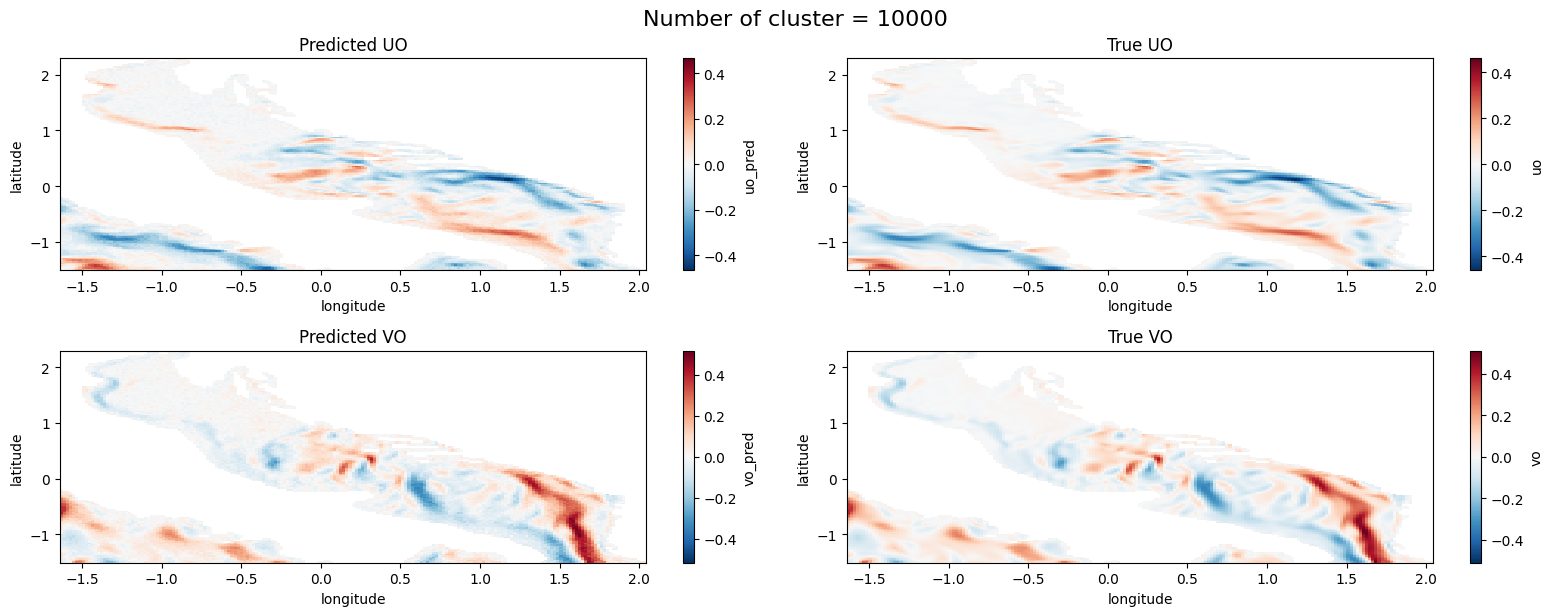

In [10]:
df_uo = xr.open_dataset("/home/igor-czudy/code/oneblue-prediction/data/raw/adriatic_currents_uo_detided_2023_2024.nc")
df_vo = xr.open_dataset("/home/igor-czudy/code/oneblue-prediction/data/raw/adriatic_currents_vo_detided_2023_2024.nc")

x_u, y_u = drop_na(uo, name='uo')
x_v, y_v = drop_na(vo, name="vo")

assert (x_u == x_v).all()
x = x_u

y = np.stack((y_u, y_v), axis=1)

rbf.create_uo_vo_plot(x, y, y_pred)


In [11]:
rbf.model

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [12]:
print("Coefficients:", rbf.model.coef_)
print("Intercept:", rbf.model.intercept_)


Coefficients: [[ -33074.24577887   -3684.64673037 -184370.72578026 ...  -71286.4475895
    20831.51598374   42663.68448398]
 [  45573.88371023  -56861.49827774  -14601.00772459 ...  -19622.49421633
    33571.17475978 -101147.56991067]]
Intercept: [ 562.53838623 -362.91566034]


In [13]:
print("Coefficients:", rbf.model.coef_.shape)
print("Intercept:", rbf.model.intercept_.shape)
# y_pred = model.intercept_ + X @ model.coef_
# (2,) = (2,) + (,2)  @ (2, 100)

Coefficients: (2, 10000)
Intercept: (2,)


In [14]:
rbf = RBFNetwork(n_clusters = 50)
rbf.train(x ,y)

RMSE for training: 0.07063481866910279
R² for training: 0.43910158071413175


In [15]:
y_pred = rbf.predict(x)

In [16]:
rbf.plot_cluster(x)

:Overlay
   .Points.I  :Points   [lon,lat]   (cluster)
   .Points.II :Points   [lon,lat]

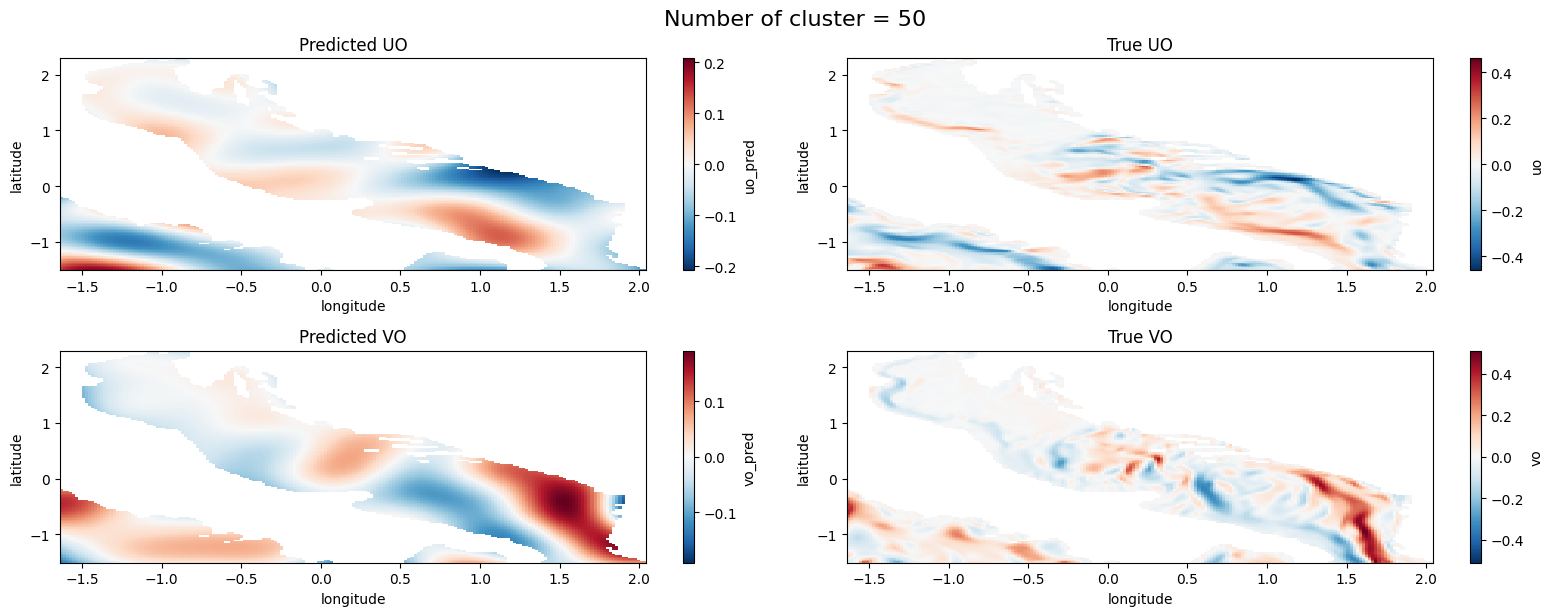

In [17]:
df_uo = xr.open_dataset("/home/igor-czudy/code/oneblue-prediction/data/raw/adriatic_currents_uo_detided_2023_2024.nc")
df_vo = xr.open_dataset("/home/igor-czudy/code/oneblue-prediction/data/raw/adriatic_currents_vo_detided_2023_2024.nc")

x_u, y_u = drop_na(uo, name='uo')
x_v, y_v = drop_na(vo, name="vo")

assert (x_u == x_v).all()
x = x_u

y = np.stack((y_u, y_v), axis=1)

rbf.create_uo_vo_plot(x, y, y_pred)
